# 🍄 Mantar Sınıflandırması – Denetimli Makine Öğrenmesi

Bu notebook, UCI Mushroom veri seti üzerinde **edible (yenilebilir) ve poisonous (zehirli)** mantarları sınıflandırmak için denetimli makine öğrenmesi yöntemlerini uygular. Her adımda açıklamalar ve görselleştirmeler mevcuttur.

## 1️⃣ Kütüphanelerin İçe Aktarılması
Proje için gerekli Python kütüphanelerini yüklüyoruz.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, NuSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from yellowbrick.classifier import ClassificationReport
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from scipy.stats import chi2_contingency
from yellowbrick.model_selection import RFECV
from sklearn.metrics import silhouette_score

## 2️⃣ Veri Yükleme ve Genel İnceleme
Veri setini yüklüyoruz, ilk satırlarını ve temel bilgilerini inceliyoruz.

In [2]:
df = pd.read_csv(r'C:\Users\Burhan Yasa\Desktop\mushrooms.csv')

df.head()
df.info()
df.dtypes
df.isna().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


## 3️⃣ Keşifsel Veri Analizi (EDA)

### 3.1. Kategorik Değişkenlerin Dağılımı
Her kategorik sütunun değer dağılımını görselleştiriyoruz.

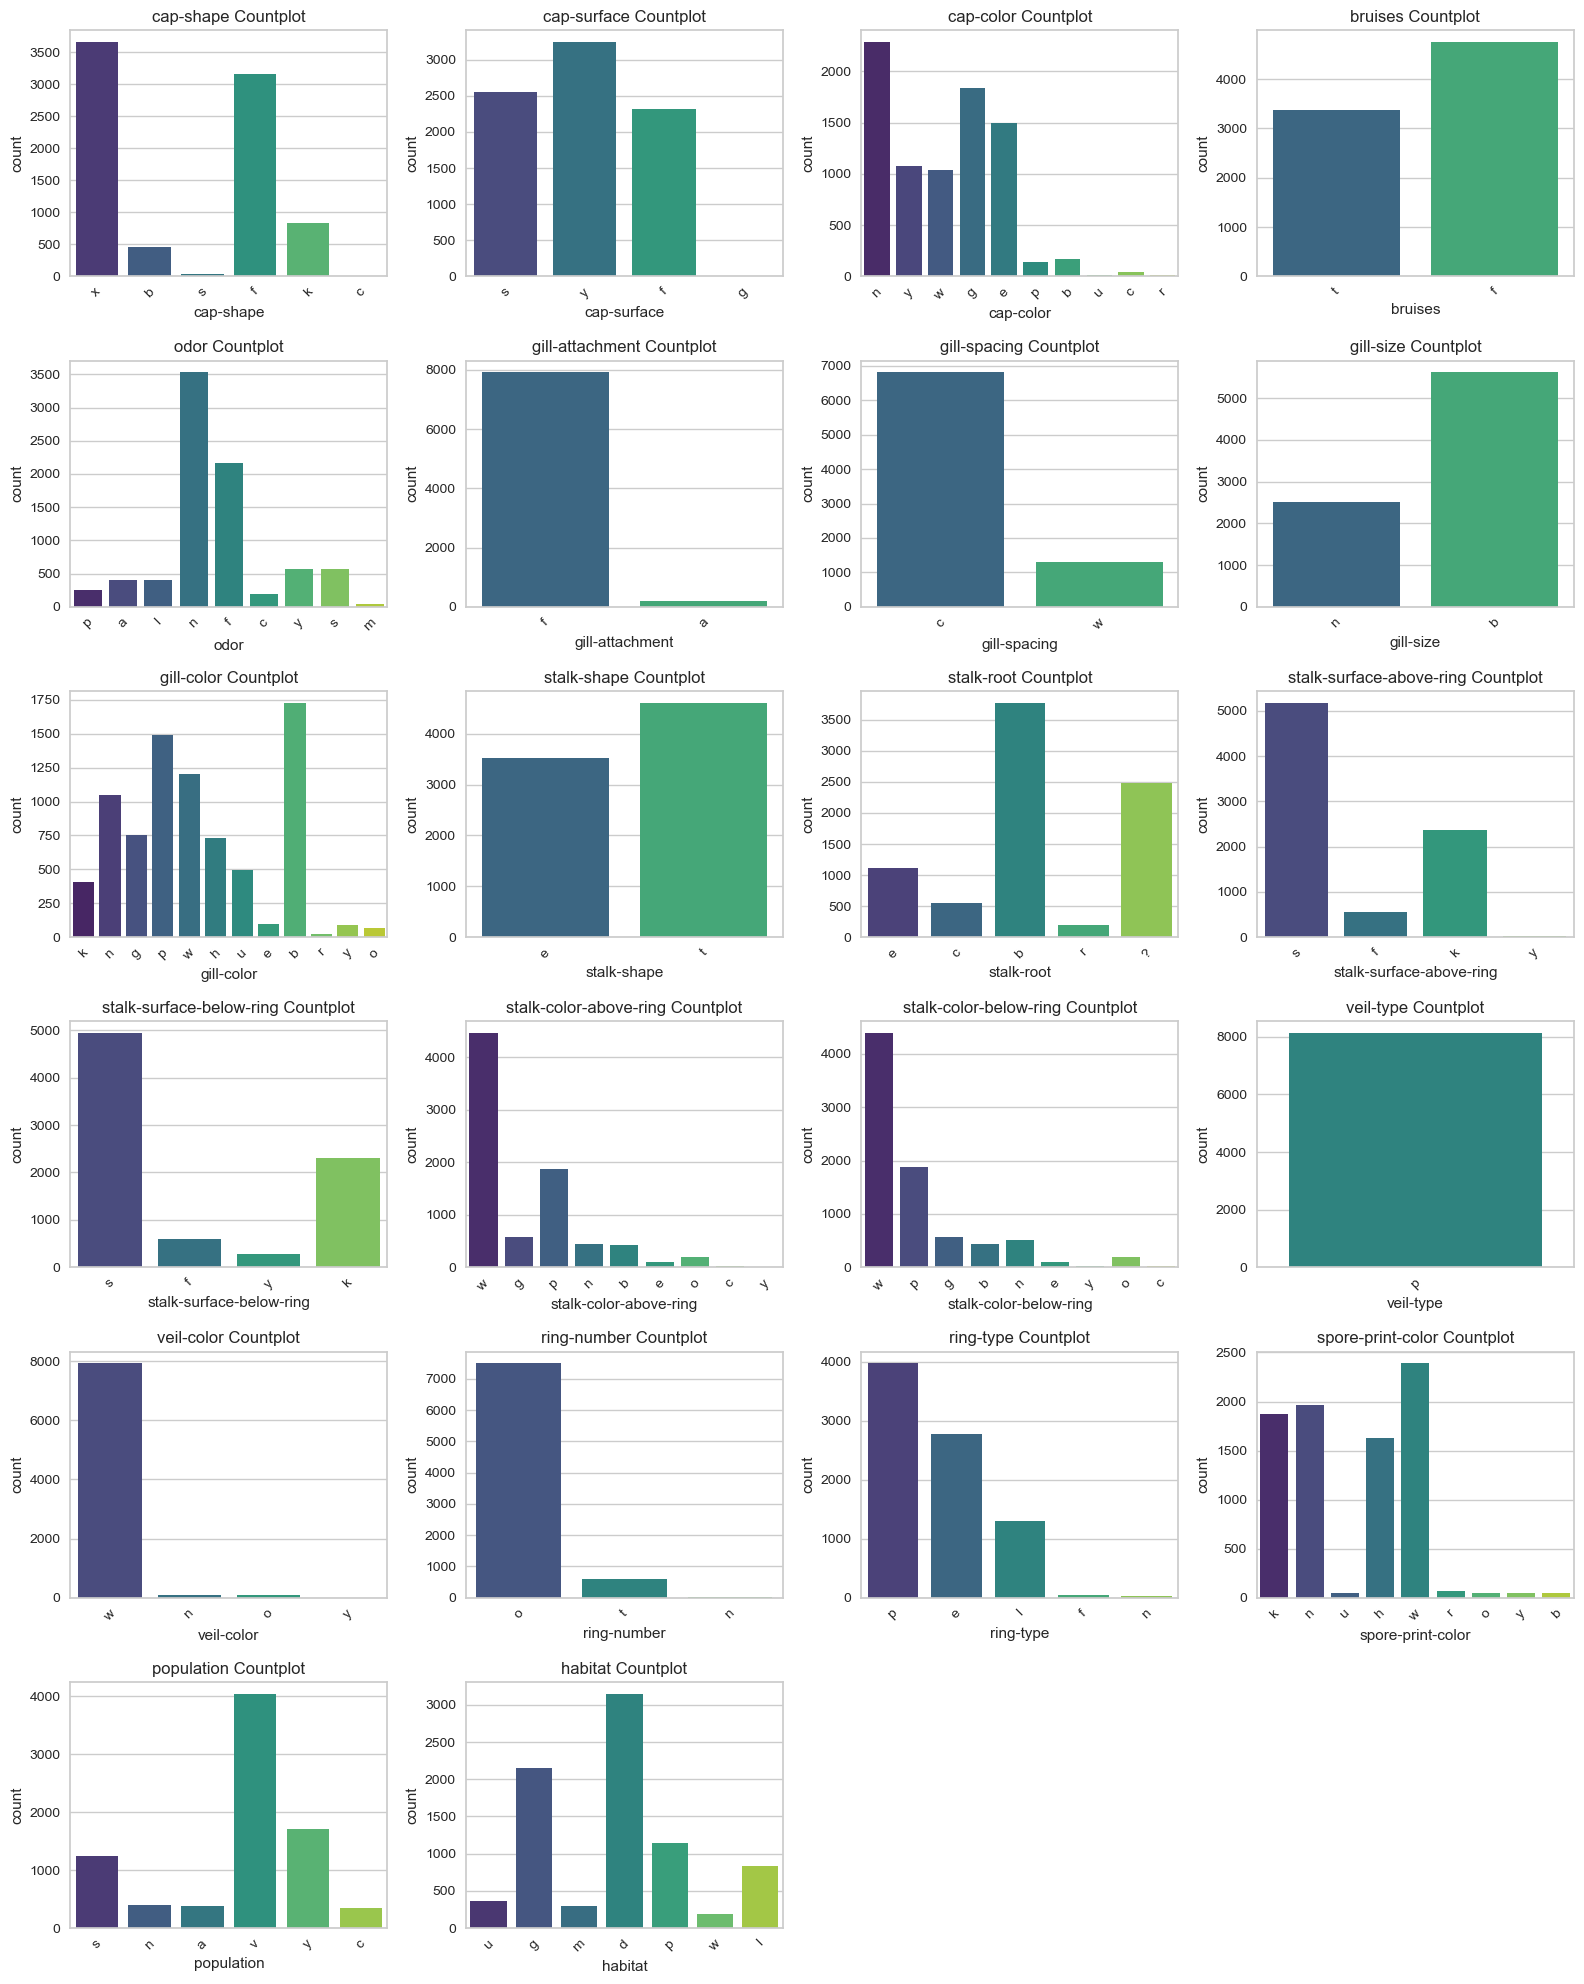

In [5]:
plt.figure(figsize=(16, 20))
for i, column in enumerate(df.columns[1:], 1):
    plt.subplot(6, 4, i)
    sns.countplot(x=column, data=df, palette="viridis")
    plt.title(f"{column} Countplot")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2. Her Sütundaki Kategorik Değişken Sayısı
Hangi sütunda kaç farklı kategori olduğunu görselleştiriyoruz.

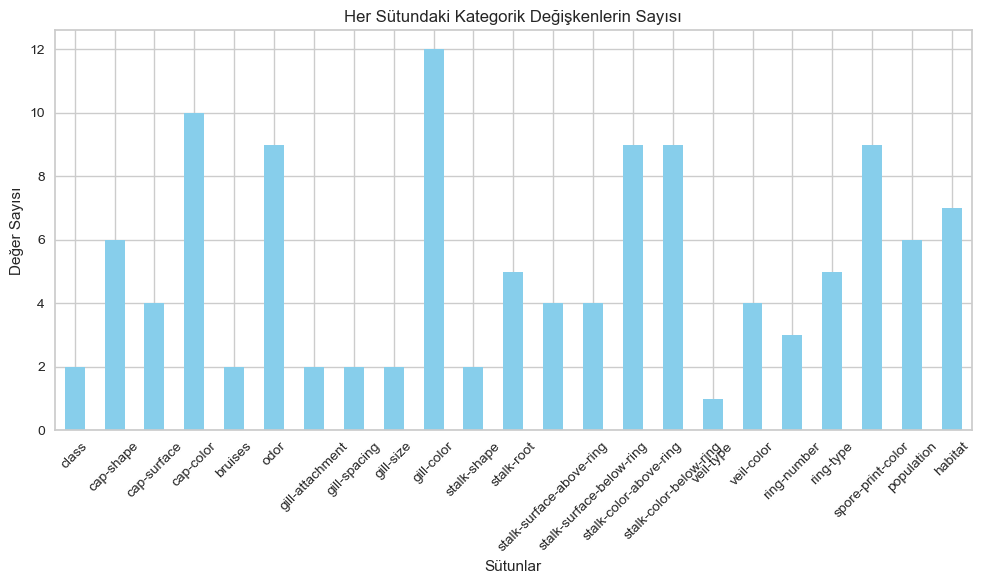

In [4]:
categorical_counts = df.apply(lambda col: col.value_counts().shape[0])
plt.figure(figsize=(10, 6))
categorical_counts.plot(kind='bar', color='skyblue')
plt.title('Her Sütundaki Kategorik Değişkenlerin Sayısı')
plt.xlabel('Sütunlar')
plt.ylabel('Değer Sayısı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3. Cramer's V Korelasyon Matrisi
Kategorik değişkenler arasındaki ilişkiyi Cramer's V metriği ile hesaplıyoruz.

C:\Users\Burhan Yasa\AppData\Local\Temp\ipykernel_10400\3791622285.py:16: RuntimeWarning: invalid value encountered in scalar divide
  matrix[i, j] = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
C:\Users\Burhan Yasa\AppData\Local\Temp\ipykernel_10400\3791622285.py:16: RuntimeWarning: invalid value encountered in scalar divide
  matrix[i, j] = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
C:\Users\Burhan Yasa\AppData\Local\Temp\ipykernel_10400\3791622285.py:16: RuntimeWarning: invalid value encountered in scalar divide
  matrix[i, j] = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
C:\Users\Burhan Yasa\AppData\Local\Temp\ipykernel_10400\3791622285.py:16: RuntimeWarning: invalid value encountered in scalar divide
  matrix[i, j] = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
C:\Users\Burhan Yasa\AppData\Local\Temp\ipykernel_10400\3791622285.py:16: RuntimeWarning: invalid value encountered in scalar divide
  matrix[i, j] = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


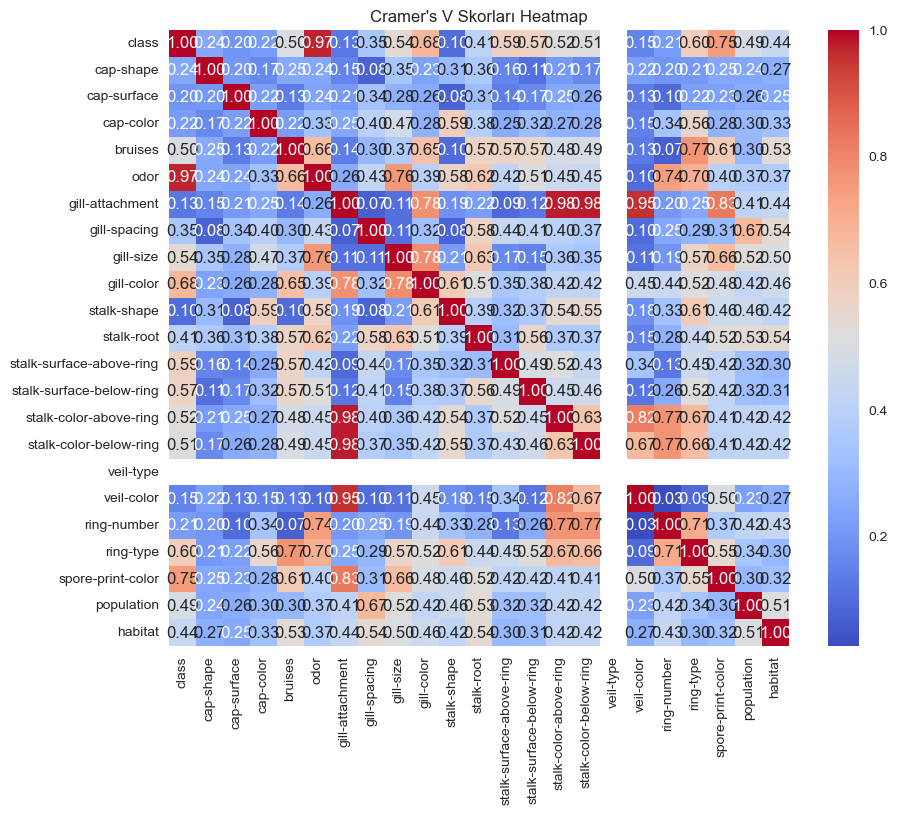

In [57]:
def cramers_v_matrix(data):
    categorical_vars = data.select_dtypes(include=['object', 'category']).columns
    n_vars = len(categorical_vars)
    matrix = np.zeros((n_vars, n_vars))
    for i, var1 in enumerate(categorical_vars):
        for j, var2 in enumerate(categorical_vars):
            if i <= j:
                confusion_matrix = pd.crosstab(data[var1], data[var2])
                chi2 = chi2_contingency(confusion_matrix)[0]
                n = confusion_matrix.sum().sum()
                phi2 = chi2 / n
                r, k = confusion_matrix.shape
                phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
                rcorr = r - ((r - 1) ** 2) / (n - 1)
                kcorr = k - ((k - 1) ** 2) / (n - 1)
                matrix[i, j] = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
                matrix[j, i] = matrix[i, j]
    return pd.DataFrame(matrix, index=categorical_vars, columns=categorical_vars)

cramer_v_results = cramers_v_matrix(df)
plt.figure(figsize=(10, 8))
sns.heatmap(cramer_v_results, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramer's V Skorları Heatmap")
plt.show()

### 3.4. Sınıfa Göre Gruplanmış Değişkenler
Bazı değişkenlerin sınıf ile olan ilişkisini stacked bar chart ile gösteriyoruz.

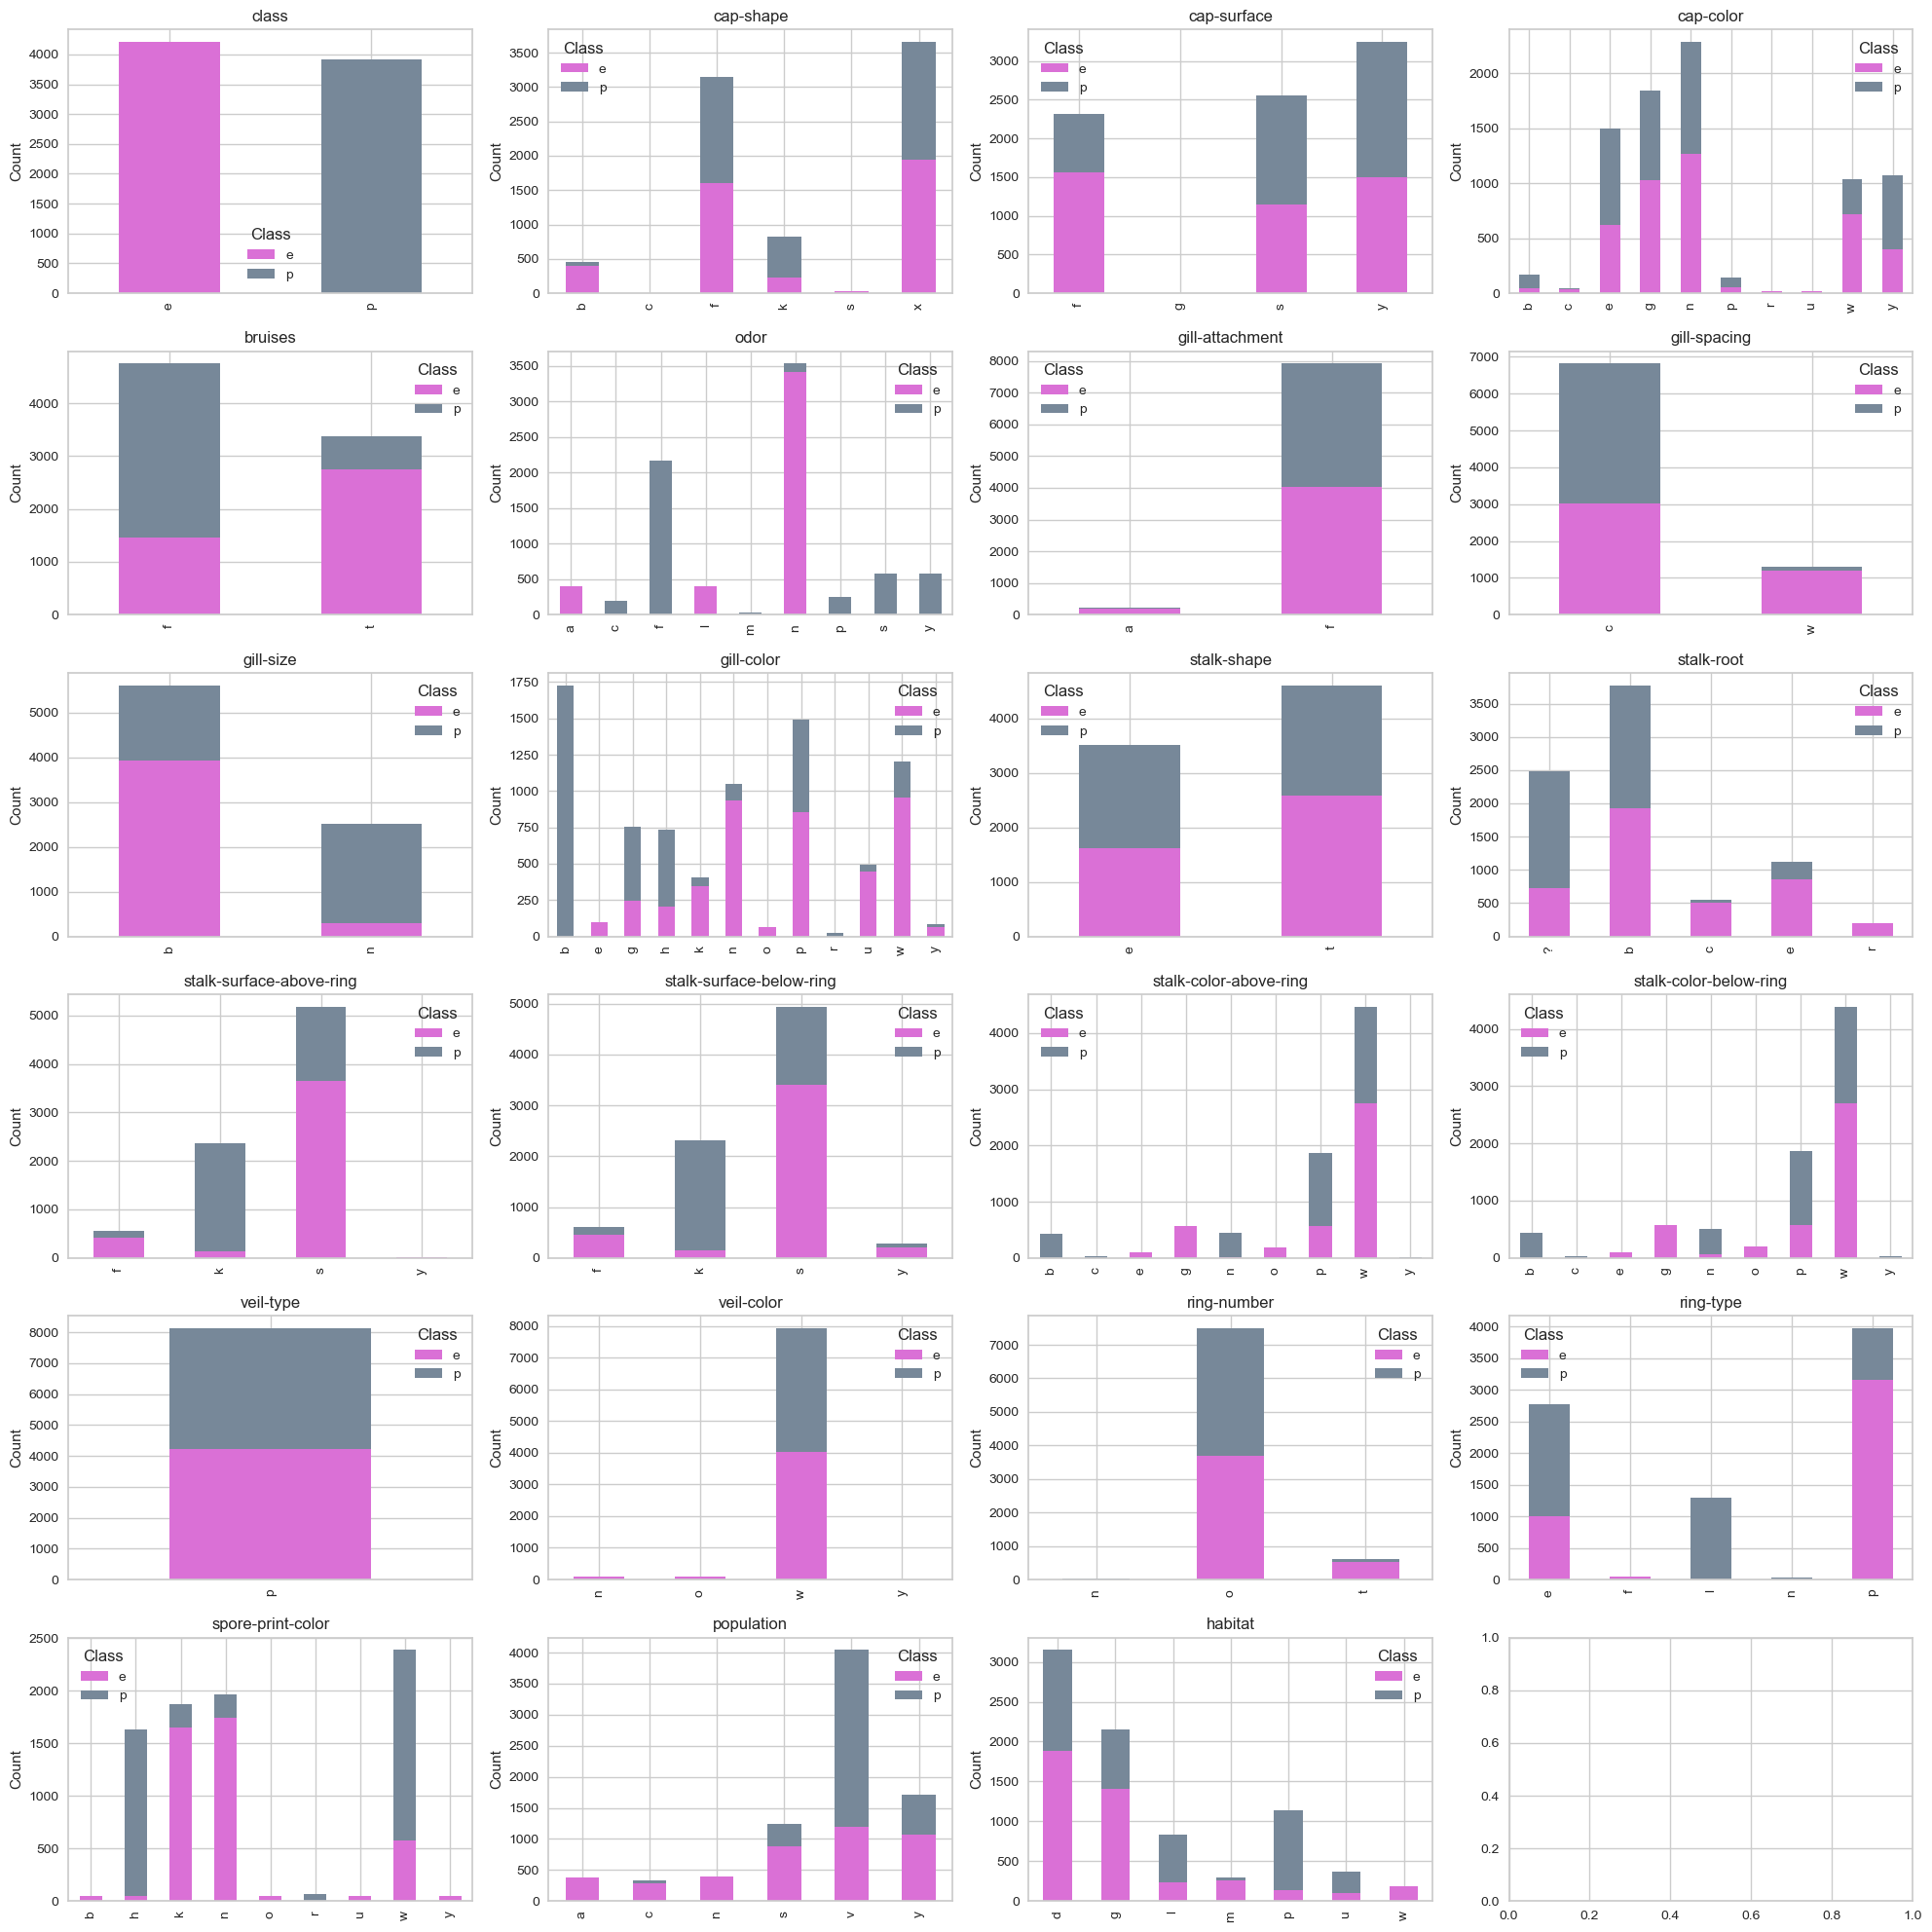

In [3]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 20))
for i, ax in enumerate(axes.flatten()):
    if i < len(df.columns):
        grouped = df.groupby([df.columns[i], 'class']).size().unstack(fill_value=0)
        colors = ["#DA70D6", "#778899"]
        grouped.plot(kind='bar', color=colors, stacked=True, ax=ax)
        ax.set_title(df.columns[i])
        ax.set_xlabel('')
        ax.set_ylabel('Count')
        ax.legend(title='Class')
plt.tight_layout()
plt.show()

## 4️⃣ Veriyi Label Encoding ile Hazırlama
Makine öğrenmesi algoritmaları için kategorik değişkenleri sayısal hale getiriyoruz.

In [5]:
label_encoder = LabelEncoder()
df_encoded = df.apply(label_encoder.fit_transform)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

## 5️⃣ Modellerin Tanımlanması ve F1 Skorları
Farklı sınıflandırma modellerini tanımlayacağız ve tüm veri seti üzerinde F1 skorlarını hesaplayacağız.

In [6]:
models = [
    SVC(gamma='auto'), NuSVC(gamma='auto'), LinearSVC(),
    SGDClassifier(max_iter=100, tol=1e-3), KNeighborsClassifier(),
    LogisticRegression(solver='lbfgs'), LogisticRegressionCV(cv=3),
    BaggingClassifier(), ExtraTreesClassifier(n_estimators=300),
    RandomForestClassifier(n_estimators=300)
]

def score_model(X, y, estimator, **kwargs):
    y_enc = LabelEncoder().fit_transform(y)
    model = Pipeline([
        ('one_hot_encoder', OneHotEncoder()),
        ('estimator', estimator)
    ])
    model.fit(X, y_enc, **kwargs)
    y_pred = model.predict(X)
    print(f"{estimator.__class__.__name__}: F1 Score = {f1_score(y_enc, y_pred)}")

for model in models:
    score_model(X, y, model)

SVC: F1 Score = 0.9989775051124744
NuSVC: F1 Score = 0.8975107773605896
LinearSVC: F1 Score = 1.0
SGDClassifier: F1 Score = 1.0
KNeighborsClassifier: F1 Score = 1.0
LogisticRegression: F1 Score = 1.0
LogisticRegressionCV: F1 Score = 1.0
BaggingClassifier: F1 Score = 1.0
ExtraTreesClassifier: F1 Score = 1.0
RandomForestClassifier: F1 Score = 1.0


## 6️⃣ Modellerin Çapraz Doğrulama ile Değerlendirilmesi (F1 & Accuracy)
Modelleri 5 katlı çapraz doğrulama ile değerlendireceğiz ve görselleştireceğiz.

C:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

C:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

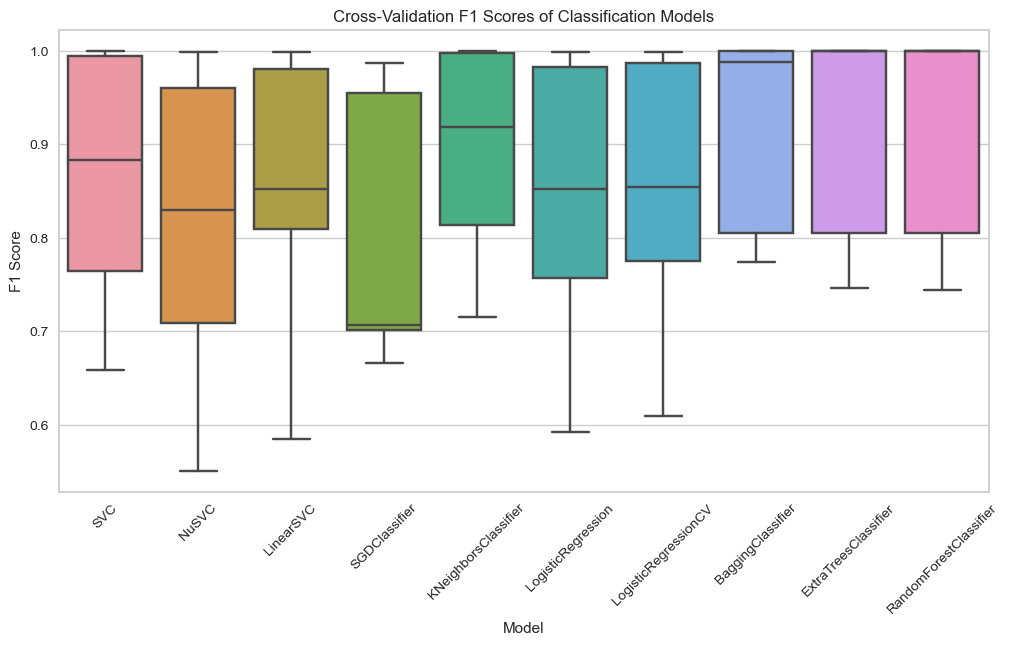

C:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

C:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

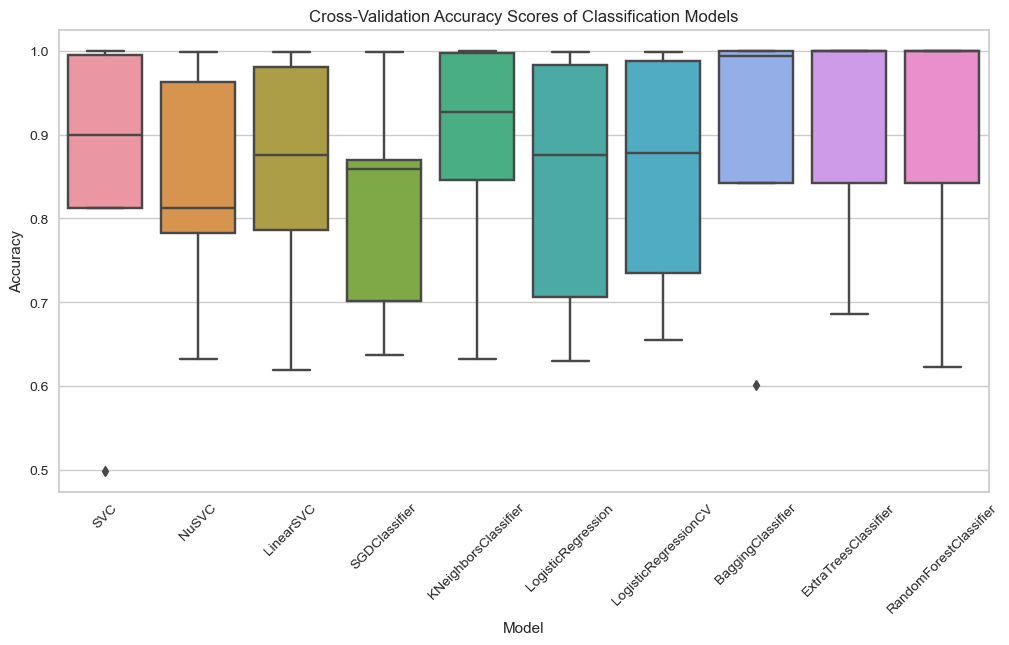

In [61]:
models_cv = [
    ("SVC", SVC()),
    ("NuSVC", NuSVC()),
    ("LinearSVC", LinearSVC()),
    ("SGDClassifier", SGDClassifier()),
    ("KNeighborsClassifier", KNeighborsClassifier()),
    ("LogisticRegression", LogisticRegression()),
    ("LogisticRegressionCV", LogisticRegressionCV(cv=3)),
    ("BaggingClassifier", BaggingClassifier()),
    ("ExtraTreesClassifier", ExtraTreesClassifier()),
    ("RandomForestClassifier", RandomForestClassifier())
]

cv_results = []
model_names = []

for name, model in models_cv:
    scores = cross_val_score(model, X, y, scoring='f1', cv=5)
    cv_results.extend(scores)
    model_names.extend([name] * len(scores))

df_scores = pd.DataFrame({"Model": model_names, "F1 Score": cv_results})

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scores, x="Model", y="F1 Score")
plt.title('Cross-Validation F1 Scores of Classification Models')
plt.xticks(rotation=45)
plt.show()

# Accuracy için
cv_results_acc = []
model_names_acc = []

for name, model in models_cv:
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=5)
    cv_results_acc.extend(scores)
    model_names_acc.extend([name]*len(scores))

df_scores_acc = pd.DataFrame({"Model": model_names_acc, "Accuracy": cv_results_acc})
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scores_acc, x="Model", y="Accuracy")
plt.title('Cross-Validation Accuracy Scores of Classification Models')
plt.xticks(rotation=45)
plt.show()

## 7️⃣ KNN Modeli ve GridSearchCV ile Hiperparametre Optimizasyonu
KNN modelini farklı n_neighbors ve mesafe metrikleri ile optimize ediyoruz.

In [62]:
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': range(1, 20),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev']
}

grid_search_knn = GridSearchCV(knn, param_grid, cv=5)
grid_search_knn.fit(X, y)

print("En İyi Hiperparametreler (KNN):", grid_search_knn.best_params_)
print("En İyi Skor (KNN):", grid_search_knn.best_score_)

En İyi Hiperparametreler (KNN): {'metric': 'manhattan', 'n_neighbors': 2, 'weights': 'uniform'}
En İyi Skor (KNN): 0.9258835922697992


## 8️⃣ Logistic Regression ve GridSearchCV
Logistic Regression modelini optimize ediyoruz ve çapraz doğrulama ile performansını ölçüyoruz.

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

param_grid_lr = {'C': [0.1, 1, 10, 100], 'penalty': ['l2']}
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=500), param_grid_lr, cv=5)
grid_search_lr.fit(X_train, y_train)

print("En İyi Parametreler (LR):", grid_search_lr.best_params_)
print("En İyi Skor (LR):", grid_search_lr.best_score_)

Accuracy: 0.9661538461538461


C:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

En İyi Parametreler (LR): {'C': 100, 'penalty': 'l2'}
En İyi Skor (LR): 0.9704572748267898


## 9️⃣ ROC Eğrisi ve ROC-AUC Skoru
Logistic Regression modelinin ROC eğrisini çiziyoruz ve AUC skorunu hesaplıyoruz.

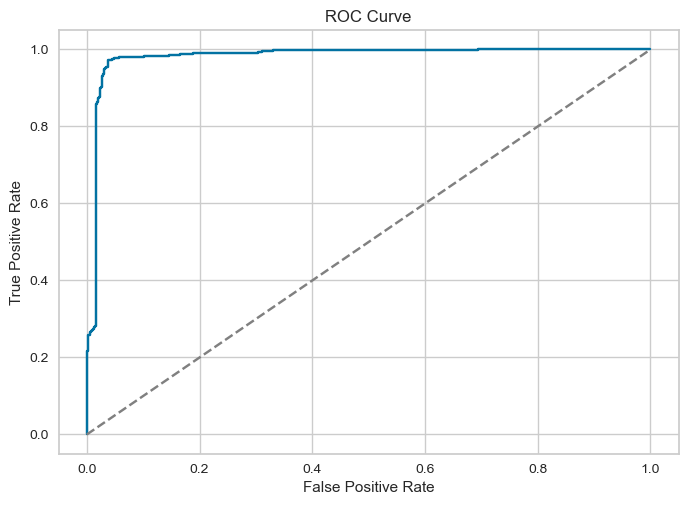

ROC AUC Score: 0.9818803978849847


In [64]:
y_pred_proba = log_reg.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC Score:", roc_auc)

## 1️⃣0️⃣ Feature Selection: RFECV ve Sequential Feature Selection
Random Forest ve Sequential Feature Selection ile en iyi özellikleri seçiyoruz.

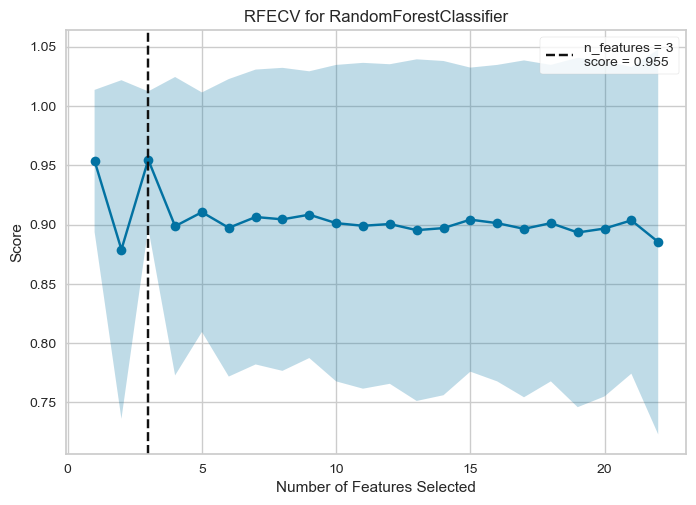

En iyi 3 özellik: Index(['cap-surface', 'odor', 'gill-size'], dtype='object')


In [8]:
X_encoded = pd.get_dummies(X) 

# 2. RFECV (Rapor Sayfa 19'daki o özel grafik)
from yellowbrick.model_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(5)
# Önemli: X yerine X_encoded kullanıyoruz
visualizer = RFECV(RandomForestClassifier(random_state=42), cv=cv, scoring='accuracy')
visualizer.fit(X_encoded, y)
visualizer.show()

# 3. Sequential Feature Selection (En iyi 3 özellik)
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
sfs = SFS(model_rf, k_features=3, forward=True, floating=False, scoring='accuracy', cv=5)
sfs.fit(X_encoded, y)

selected_features_idx = sfs.k_feature_idx_
selected_features_names = X_encoded.columns[list(selected_features_idx)]
print("En iyi 3 özellik:", selected_features_names)

# Cross Validation Scores for RandomForestClassifier

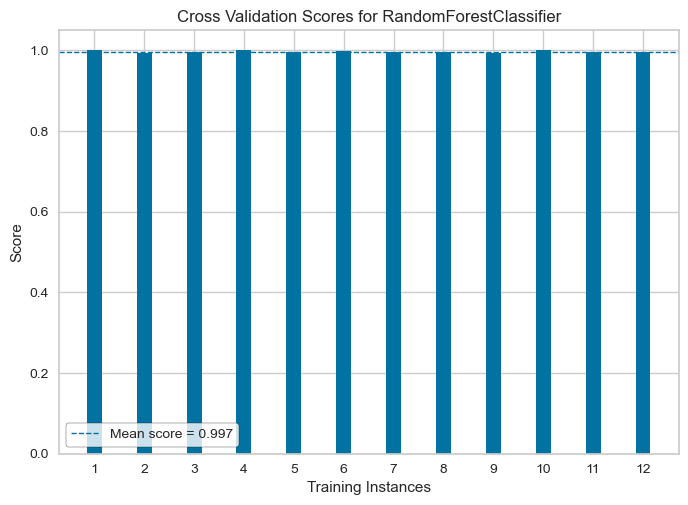

<AxesSubplot:title={'center':'Cross Validation Scores for RandomForestClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from yellowbrick.model_selection import CVScores # Eksik olan kısım burası

# 1. Hiperparametre Optimizasyonu
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 2. En İyi Parametrelerle Görselleştirme
X = df[['cap-color', 'odor', 'spore-print-color']]
y = df["class"]

cv_strategy = StratifiedKFold(n_splits=12, shuffle=True, random_state=42)

# GridSearchCV'den gelen en iyi parametreleri (n_estimators=50 vb.) burada kullanıyorsun
visualizer = CVScores(
    RandomForestClassifier(**grid_search.best_params_, random_state=42), 
    cv=cv_strategy
)

visualizer.fit(X, y)
visualizer.show()

## 1️⃣1️⃣ Random Forest Hiperparametre Optimizasyonu
Random Forest modelinin n_estimators, max_depth ve min_samples parametrelerini GridSearchCV ile optimize ediyoruz.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=3, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)

print("En iyi parametreler (RF):", grid_search_rf.best_params_)
print("En iyi doğruluk (RF):", grid_search_rf.best_score_)

En iyi parametreler (RF): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
En iyi doğruluk (RF): 1.0


## 1️⃣2️⃣ Seçilen Özelliklerle Model Eğitimi ve Cross-Validation
Seçilen önemli özelliklerle Random Forest modelini eğitiyoruz.

In [10]:
selected_features = ['cap-color', 'odor', 'spore-print-color']
X_selected = df[selected_features]
y = df['class']

X_encoded = pd.get_dummies(X_selected)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=50, max_depth=None, min_samples_split=2, min_samples_leaf=1)
rf_model.fit(X_train, y_train)
cv_scores = cross_val_score(rf_model, X_encoded, y, cv=5)
print("Cross-Validation Scores (RF with selected features):", cv_scores)
print("Mean CV Score:", cv_scores.mean())

Cross-Validation Scores (RF with selected features): [0.84246154 0.99692308 0.98830769 1.         0.69458128]
Mean CV Score: 0.904454717696097


## 1️⃣3️⃣ Decision Tree ile Görselleştirme
Tek bir karar ağacı ile veri setini görselleştiriyoruz.

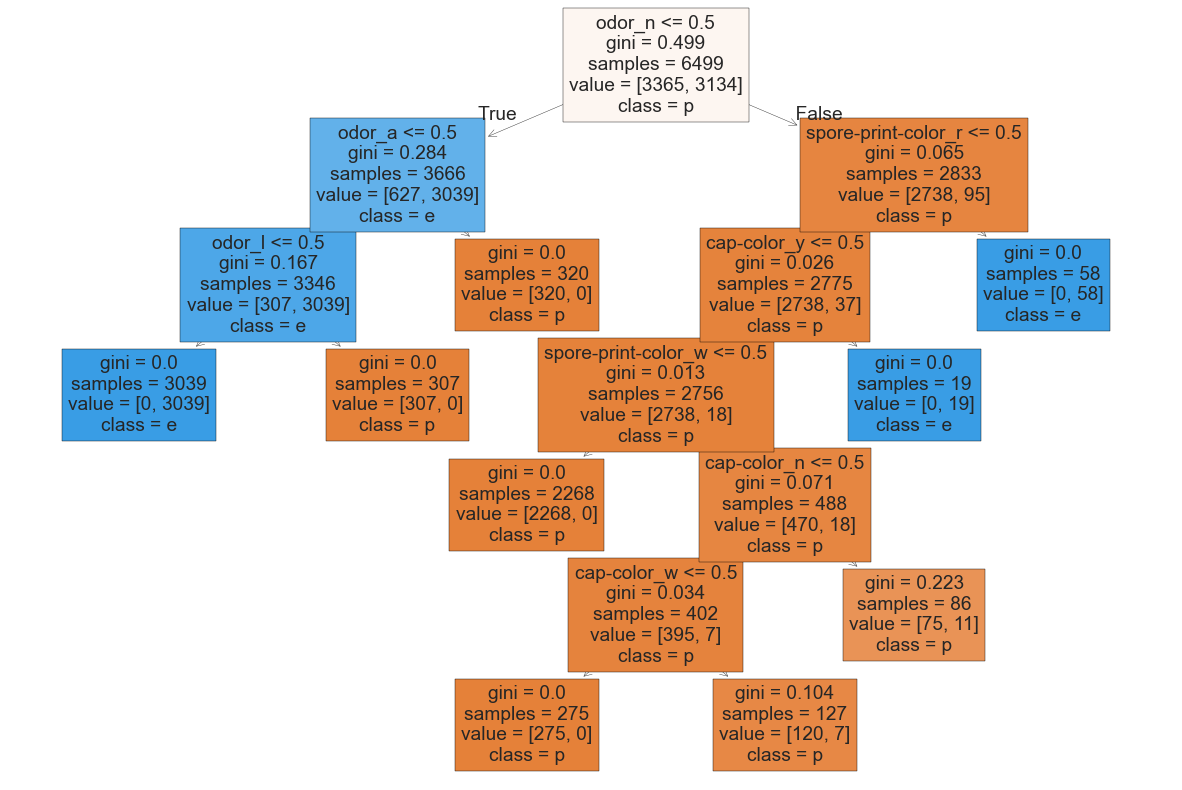

In [74]:
single_tree_model = DecisionTreeClassifier(random_state=42)
single_tree_model.fit(X_train, y_train)

plt.figure(figsize=(15, 10))
plot_tree(single_tree_model, feature_names=X_encoded.columns, class_names=y.unique().astype(str), filled=True)
plt.show()

## 1️⃣5️⃣ K-Means Kümeleme ve PCA Görselleştirmesi
K-means algoritması ile veri kümelerini buluyor ve PCA ile 2 boyutlu görselleştiriyoruz.

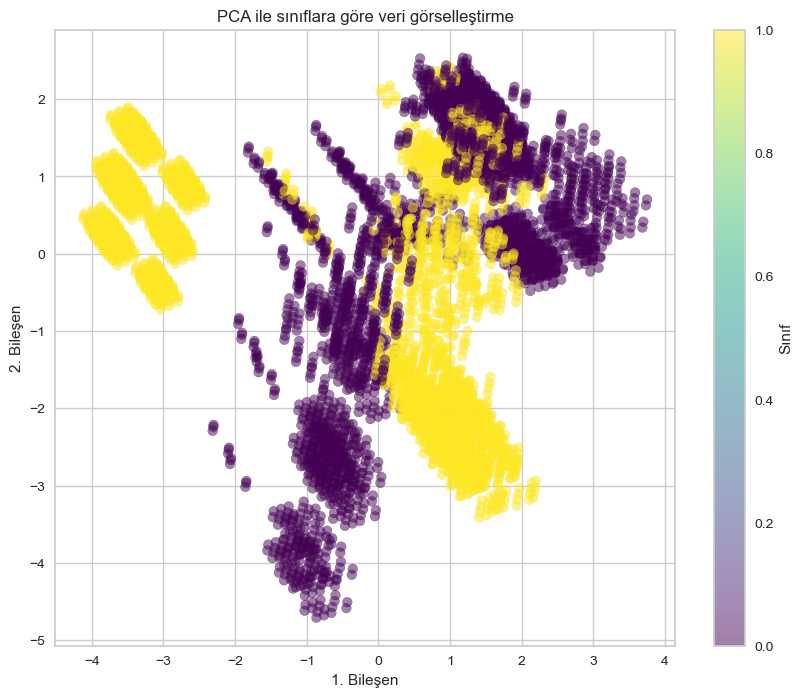

In [15]:
# Önce verileri standartlaştırma
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA modelini oluşturma ve uygulama
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Sınıflara göre renklendirilmiş scatter plot çizimi
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.5)
plt.title('PCA ile sınıflara göre veri görselleştirme')
plt.xlabel('1. Bileşen')
plt.ylabel('2. Bileşen')
plt.colorbar(label='Sınıf')
plt.grid(True)
plt.show()

## 1️⃣6️⃣ Silhouette Score ile K-Means Değerlendirmesi
Farklı küme sayıları için silhouette skorlarını hesaplayıp görselleştiriyoruz.

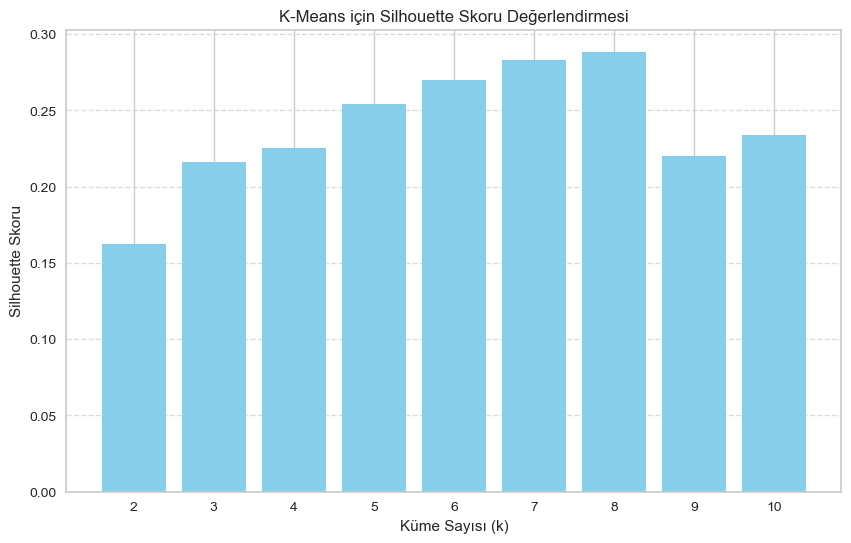

In [19]:
# 1. Veriyi Sayısallaştırma (Encoding)
X_encoded = pd.get_dummies(df.drop('class', axis=1))

k_values = range(2, 11)
silhouette_scores = []

# 2. Döngü İçerisinde Sayısal Veriyi Kullanma
for k in k_values:
    # X yerine X_encoded kullanarak sayısal veri üzerinden işlem yapıyoruz
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_encoded)
    
    # Skor hesaplaması için de sayısal veriyi (X_encoded) veriyoruz
    silhouette_avg = silhouette_score(X_encoded, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# 3. Görselleştirme
plt.figure(figsize=(10,6))
plt.bar(k_values, silhouette_scores, color='skyblue')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Silhouette Skoru')
plt.title('K-Means için Silhouette Skoru Değerlendirmesi')
plt.xticks(np.arange(min(k_values), max(k_values)+1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

------------

# K Means(Unsupervised) Clustering

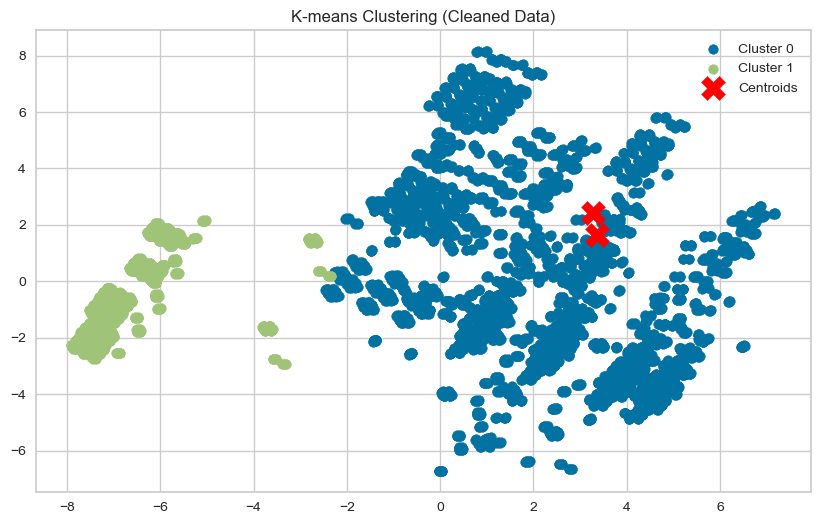

In [33]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 'class' sütununu ayır (eğer varsa)
if 'class' in df.columns:
    df_data = df.drop('class', axis=1)
else:
    df_data = df.copy()

# 2. Tüm veriyi sayıya zorla (Sayı olmayanlar NaN olur)
X_numeric = df_data.apply(pd.to_numeric, errors='coerce')

# 3. Boş kalan sütunları ve satırları temizle
X = X_numeric.dropna(axis=1, how='all')
X = X.dropna()

# 4. K-means ve Görselleştirme
if not X.empty:
    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans.fit(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 6))
    for i in range(2):
        plt.scatter(X_pca[kmeans.labels_ == i, 0], X_pca[kmeans.labels_ == i, 1], label=f'Cluster {i}')

    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
    plt.title('K-means Clustering (Cleaned Data)')
    plt.legend()
    plt.show()